# Analysing PMF for Lammps mW NpT simulations no weighting

In [64]:
import matplotlib as mpl
#mpl.rcParams.update(mpl.rcParamsDefault)
import numpy as np
import matplotlib.pyplot as plt


In [65]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


In [66]:
writepmf = False

Rs=2
T=300
L=60
dl=0.05
kB=1.38E-23
sig_mw=2.3925

In [67]:
ipDir=f"/Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_Sphere_pmf/Brute_force/Attractive_solute/Mary_potential/P0_Rs{Rs}/"
opdir = f"/Users/phxnw/Dropbox/Hydrophobicity/density-fluct/LCW crossover Figs/PMFs"
print(ipDir)

/Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_Sphere_pmf/Brute_force/Attractive_solute/Mary_potential/P0_Rs2/


In [68]:
def extract_pmf(dL,L):
    count=0
    rlist=[]
    Vlist=[]
    whtlist=[]
    bin_size = dL
    max_dist = L/2.0


    with open(xyzfilename) as f:
        r2_coords = None
        skip_next = False
    
        for line in f:
            s = line.strip()
            if not s:
                continue
        
                # XYZ frame boundary: first line is natoms
            if s.isdigit():
                r2_coords = None          # IMPORTANT: don't carry over between frames
                skip_next = True          # next line is comment
                continue
        
            if skip_next:
                skip_next = False
                continue
        
            elements = s.split()
            if len(elements) == 4 and elements[0] == "2":
                r2_coords = np.array(elements[1:4], dtype=np.float32)
        
            elif len(elements) == 4 and elements[0] == "3" and r2_coords is not None:
                r3_coords = np.array(elements[1:4], dtype=np.float32)
                dr = r3_coords - r2_coords
                dr -= L * np.rint(dr / L)
                sep = np.sqrt(np.dot(dr, dr))
        
                rlist.append(sep)
                count += 1
                if sep < 2*Rs-1:
                  print(sep, r2_coords, r3_coords)


    whtlist=np.ones(len(rlist))
    print('length of rlist=',len(rlist))
    bins = np.arange(0, max_dist+bin_size, bin_size)
    hist, bin_edges = np.histogram(rlist, bins=bins, density=True, weights=whtlist)


    r = np.asarray(rlist)

    print("len(r):", r.size)
    print("min/max:", np.nanmin(r), np.nanmax(r))
    print("NaN:", np.isnan(r).sum(), " inf:", np.isinf(r).sum())

    bins = np.arange(0, max_dist + bin_size, bin_size)
    lo, hi = bins[0], bins[-1]

    inrange = (r >= lo) & (r <= hi)   # <= hi to match histogram’s last bin inclusion
    finite  = np.isfinite(r)

    print("finite:", finite.sum())
    print("in [lo,hi]:", (finite & inrange).sum())
    print("below lo:", (finite & (r < lo)).sum())
    print("above hi:", (finite & (r > hi)).sum())

    hist, edges = np.histogram(r[finite], bins=bins, weights=np.ones((finite).sum()))
    print("sum(hist):", hist.sum())
    return bin_edges,hist,count


In [69]:
def extract_pmf_from_colvar(colvarfilename, dL, L):
    # one-line header, separations in 2nd column
    r = np.loadtxt(colvarfilename, skiprows=1, usecols=1)
    r = r[np.isfinite(r)]

    bin_size = dL
    max_dist = L/2.0
    bins = np.arange(0, max_dist + bin_size, bin_size)

    # match your notebook behaviour: COUNTS per bin (not density)
    hist, bin_edges = np.histogram(r, bins=bins, weights=np.ones_like(r))
    return bin_edges, hist, r.size


In [70]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


processing P=0, T=300, D0=0.01, Rs=2
length of rlist= 203842
len(r): 203842
min/max: 3.625388 18.161308
NaN: 0  inf: 0
finite: 203842
in [lo,hi]: 203842
below lo: 0
above hi: 0
sum(hist): 203842.0
number of data point= 203842
number of COLVAR data point= 1560396


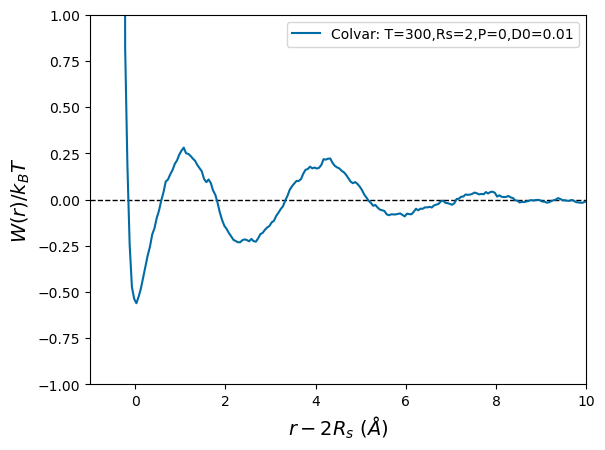

In [71]:
plt.style.use('tableau-colorblind10')

cases = {
    3: [
        (0, 300, 0.01),
        (500, 300, 0.01),
        (1000, 300, 0.01),
        (2000, 300, 0.01),
    ],
    2.5: [
        (0, 300, 0.01),
    ],
    2: [
        (0, 300, 0.01),
#        (0, 360, 0.01),
#        (1000, 300, 0.01),
#        (2000, 300, 0.01),
    ],
    1.7: [
        (0, 300, 0.01),
#        (1000, 300, 0.01),
#        (2000, 300, 0.01),
    ],
    1.4: [
        (0, 300, 0.01),
  #      (1000, 300, 0.01),
  #      (2000, 300, 0.01),
  #      (4000, 300, 0.01)
  #      (0, 300, 0.1),
  #      (1000, 300, 0.1),
    ],
}


params = cases[Rs]
for P, T, D0 in params:
    print(f"processing P={P}, T={T}, D0={D0}, Rs={Rs}")
    shift=2*Rs
    plt.ylim(-1,top=Rs/2)
    plt.xlim(-1.0,10)
    plt.xlabel(r'$r-2R_s~$($\AA$)',fontsize=14)
    plt.ylabel(r'$W(r)/k_BT$',fontsize=14)
    
    xyzfilename = ipDir+"sep_T{}.P{}.Rs{}.D0{}.xyz".format(T,P,Rs,D0)
    bin_edges, hist0, count  = extract_pmf(dl,L)
    print('number of data point=',count)
    
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2.0
    #print(bin_centers)
    
    Pigr = 4*np.pi*bin_centers**2/(L**3)
    rdf = hist0 / Pigr
    rdf[rdf <= 0] = 1e-10

    # x = r - 2Rs
    x = bin_centers - shift
    
    # Use bins in x ∈ [10, 11] to set the baseline
    mask = (x >= 12.0) & (x <= 14.0)
    
    if np.any(mask):
        # Shift PMF so that mean PMF in mask range is zero
        pmf = -np.log(rdf)
        pmf -= np.mean(pmf[mask])
    else:
        # Fallback: previous behaviour (or pick another fallback you prefer)
        scale = np.mean(rdf[-30:])
        rdfs  = rdf / scale
        pmf   = -np.log(rdfs)
    
 #   plt.plot(x, smooth(pmf, 4), marker='none', linestyle='--',label=rf"Dump: Rs={Rs},p={P}")
    plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
    if(writepmf):
        path=ipDir+"pmf_Rs_{}_T{}_P{}.dat".format(Rs,T,P)
        oppmf=open(path,"w")
        points=[bin_centers,pmf]
        for x in zip(*points):
            oppmf.write("{0}\t{1}\n".format(*x))
        oppmf.close()          
    

    # --- COLVAR-based PMF on same bins ---
    
    colvarfilename = ipDir+"COLVAR-T{}-P{}-Rs{}-D0{}".format(T,P,Rs,D0)
    bin_edges_c, hist_c, count_c = extract_pmf_from_colvar(colvarfilename, dl, L)
    print('number of COLVAR data point=',count_c)
    
    # use SAME bin_centers & Pigr (same bins), so overlay is consistent
    rdf_c = hist_c / Pigr
    rdf_c[rdf_c <= 0] = 1e-10
    
    pmf_c = -np.log(rdf_c)
    pmf_c -= np.mean(pmf_c[mask])

    pmf_c=smooth(pmf_c,5)
    bin_centers = 0.5 * (bin_edges_c[:-1] + bin_edges_c[1:])
    x=bin_centers -shift
    y=pmf_c
    
    plt.plot(x, y, label=rf"Colvar: T={T},Rs={Rs},P={P},D0={D0}")
    
    #plt.ylabel("F / kBT")
    plt.legend()
    import os
    os.makedirs(opdir, exist_ok=True)
    outfile = os.path.join(opdir,f"pmf_T{T:.1f}_P{P:.1f}_Rs{Rs:.1f}_D0{D0:.2f}.dat")
    np.savetxt(outfile,np.column_stack((x, y)),header="r_minus_2Rs_A,    PMF_over_kBT")


plt.show()



processing p=0, T=300, D0=0.01, Rs=2
length of rlist= 203842
len(r): 203842
min/max: 3.625388 18.161308
NaN: 0  inf: 0
finite: 203842
in [lo,hi]: 203842
below lo: 0
above hi: 0
sum(hist): 203842.0
number of data point= 203842
number of COLVAR data point= 1560396
Rs 2


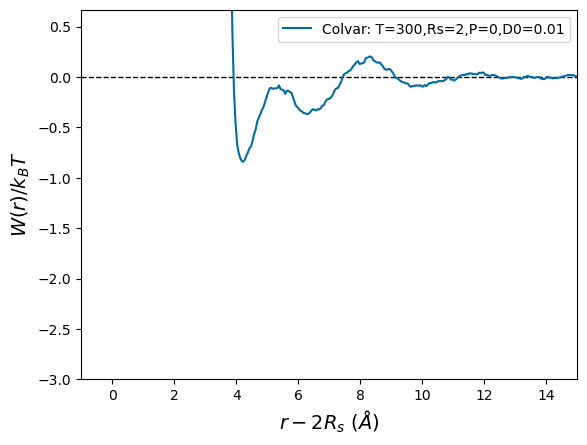

In [72]:
#Here we add in a LJ solute-solute to compare with literature

plt.style.use('tableau-colorblind10')

for P, T, D0 in params:
    print("processing p={P}, T={T}, D0={D0}, Rs={Rs}".format(P=P, T=T, D0=D0, Rs=Rs))
    shift=2*Rs
    plt.ylim(-3,top=Rs/3)
    plt.xlim(-1.0,15)
    plt.xlabel(r'$r-2R_s~$($\AA$)',fontsize=14)
    plt.ylabel(r'$W(r)/k_BT$',fontsize=14)
    
    xyzfilename = ipDir+"sep_T{}.P{}.Rs{}.D0{}.xyz".format(T,P,Rs,D0)
    bin_edges, hist0, count  = extract_pmf(dl,L)
    print('number of data point=',count)
    
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2.0
    #print(bin_centers)
    
    Pigr = 4*np.pi*bin_centers**2/(L**3)
    rdf = hist0 / Pigr
    rdf[rdf <= 0] = 1e-10

    # x = r - 2Rs
    x = bin_centers #- shift
    
    # Use bins in x ∈ [10, 11] to set the baseline
    mask = (x >= 12.0) & (x <= 14.0)
    
    if np.any(mask):
        # Shift PMF so that mean PMF in mask range is zero
        pmf = -np.log(rdf)
        pmf -= np.mean(pmf[mask])
    else:
        # Fallback: previous behaviour (or pick another fallback you prefer)
        scale = np.mean(rdf[-30:])
        rdfs  = rdf / scale
        pmf   = -np.log(rdfs)
    
 #   plt.plot(x, smooth(pmf, 4), marker='none', linestyle='--',label=rf"Dump: Rs={Rs},p={P}")
    plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
    if(writepmf):
        path=ipDir+"pmf_Rs_{}_T{}_P{}.dat".format(Rs,T,P)
        oppmf=open(path,"w")
        points=[bin_centers,pmf]
        for x in zip(*points):
            oppmf.write("{0}\t{1}\n".format(*x))
        oppmf.close()          
    

    # --- COLVAR-based PMF on same bins ---
    
    colvarfilename = ipDir+"COLVAR-T{}-P{}-Rs{}-D0{}".format(T,P,Rs,D0)
    bin_edges_c, hist_c, count_c = extract_pmf_from_colvar(colvarfilename, dl, L)
    print('number of COLVAR data point=',count_c)
    
    # use SAME bin_centers & Pigr (same bins), so overlay is consistent
    rdf_c = hist_c / Pigr
    rdf_c[rdf_c <= 0] = 1e-10
    
    pmf_c = -np.log(rdf_c)
    pmf_c -= np.mean(pmf_c[mask])

    pmf_c=smooth(pmf_c,4)
    
    # plt.plot(x, pmf_c, label=rf"Colvar: T={T},Rs={Rs},P={P},D0={D0}")

    # x = r-2Rs
    def attraction(r, _eps,_sigma):
        
        u = 4*_eps*( (_sigma/(r) )**12 - (_sigma/(r))**6)
        u[r<=0] = np.nan
        return u


    s = 2*Rs
    print("Rs",Rs)
    eps = 0.55
    plt.plot(x, pmf_c+attraction(x,_eps=eps, _sigma=s),
             label=rf"Colvar: T={T},Rs={Rs},P={P},D0={D0}")
    # plt.plot(x, attraction(x,_eps=eps, _sigma=s), label=rf"Colvar: T={T},Rs={Rs},P={P},D0={D0}")

    #plt.ylabel("F / kBT")
    plt.legend()


plt.show()

